#  GAN Implementation in PyTorch

In this notebook, we explore **Generative Adversarial Networks (GANs)**, a framework for estimating generative models via an adversarial process. Two models are trained simultaneously: a generative model $G$ that captures the data distribution, and a discriminative model $D$ that estimates the probability that a sample came from the training data rather than $G$.

## 1. Model Architecture
The GAN consists of two main networks competing against each other:

*   **The Generator:**
    *   **Goal:** Create realistic images from random noise to fool the discriminator.
    *   **Mechanism:** Takes a random latent vector $z$ and upsamples it into an image.
    *   **Layers:** We use **Transposed Convolutional Layers** to upsample the spatial dimensions.
    *   *Structure:* Latent Vector (100) $\to$ FC $\to$ Reshape (256x8x8) $\to$ Dropout (0.2) $\to$ 3 Transposed Conv Blocks (ConvT+BatchNorm+LeakyReLU) (128, 64, 32 channels) $\to$ Transposed Conv (3 channels) $\to$ Sigmoid $\to$ Output (3x128x128).

*   **The Discriminator:**
    *   **Goal:** Distinguish between real images from the dataset and fake images from the generator.
    *   **Mechanism:** A standard binary classifier (CNN) that outputs a probability (real vs. fake).
    *   **Layers:** We use **Convolutional Layers** with stride to downsample the image.
    *   *Structure:* Input (3x128x128) $\to$ 4 Conv Blocks (Conv+BatchNorm+LeakyReLU) with increasing channels (32, 64, 128, 256) $\to$ Flatten (256x8x8) $\to$ Dropout (0.2) $\to$ FC $\to$ Sigmoid $\to$ Output (Probability).

## 2. Key Concepts & Intuition

### The Adversarial Game (Minimax Game)

**The Objective:**
The training process is a zero-sum game where:
*   **D** tries to maximize the probability of assigning the correct label to both training examples and samples from $G$.
*   **G** tries to minimize the probability that $D$ is correct (i.e., maximize the probability that $D$ thinks the fake images are real).

### The Loss Function (Binary Cross Entropy)


### Training Process
Training GANs is notoriously unstable because we are training two networks with opposing goals. We alternate updates:
1.  **Train Discriminator:** Freeze $G$, feed real and fake images to $D$, update $D$'s weights to better classify them.
2.  **Train Generator:** Freeze $D$, generate fake images, feed them to $D$, update $G$'s weights to make $D$ predict "Real".

### Inference (Generation)
Once trained, we discard the Discriminator. To generate new images, we simply sample a random vector $z$ from a Standard Normal Distribution ($\mathcal{N}(0, 1)$) and pass it through the **Generator**.

In [49]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.utils as vutils
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


### Load and explore data 

In [50]:
DATA_DIR_REAL = '/info/etu/m2/s2405959/deepLearning/AnimusVision/fox_in_snow_real'
DATA_DIR_AUG = '/info/etu/m2/s2405959/deepLearning/AnimusVision/fox_in_snow_generated'
IMG_SIZE = 128
BATCH_SIZE = 16
Z_DIM = 100

class FoxSnowDataset(Dataset):
    def __init__(self, data_dirs, img_size=128):
        self.img_size = img_size
        self.image_paths = []
        for data_dir in data_dirs:
            if os.path.exists(data_dir):
                for file in os.listdir(data_dir):
                    if file.lower().endswith(('.jpg', '.png', '.jpeg')):
                        self.image_paths.append(os.path.join(data_dir, file))
        self.transform = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor()
        ])
    def __len__(self):
        return len(self.image_paths)
    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert('RGB')
        return self.transform(img)

dataset = FoxSnowDataset([DATA_DIR_REAL, DATA_DIR_AUG], img_size=IMG_SIZE)
NUM_IMAGES = len(dataset)
if NUM_IMAGES == 0:
    raise ValueError(f"No images found in directories: {DATA_DIR_REAL} or {DATA_DIR_AUG}")

dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True, num_workers=0)
print(f"Dataset: {NUM_IMAGES} images | Batch size: {BATCH_SIZE}")

Dataset: 100 images | Batch size: 16


### Display samples 

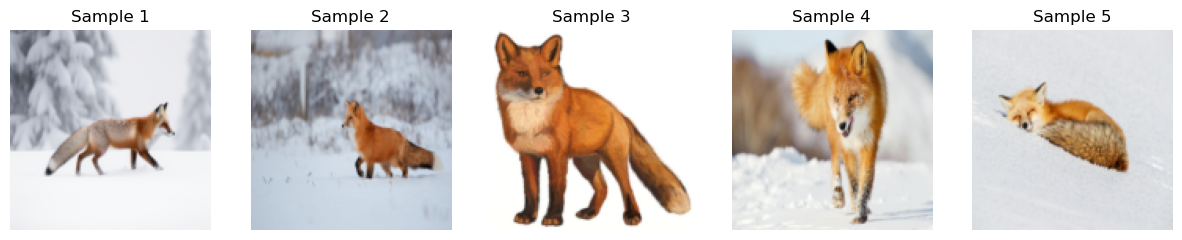

In [51]:
def show_sample_images(dataloader, num_samples=5):
    # Get a batch of images
    images = next(iter(dataloader))
    
    plt.figure(figsize=(15, 3))
    for i in range(min(num_samples, len(images))):
        plt.subplot(1, num_samples, i + 1)
        # Convert from (C, H, W) to (H, W, C) for matplotlib
        img = images[i].permute(1, 2, 0).numpy()
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"Sample {i+1}")
    plt.show()

show_sample_images(dataloader, num_samples=5)

### Create Generator

In [52]:
class Generator(nn.Module):
    def __init__(self, z_dim=100):
        super(Generator, self).__init__()
        self.z_dim = z_dim
        self.flatten_dim = 256 * 8 * 8 # (C,H,W)

        self.dec_fc = nn.Linear(z_dim, self.flatten_dim)
        self.dropout = nn.Dropout(0.2)
        # apply padding for input and output
        self.dec_conv1 = nn.ConvTranspose2d(256, 128, kernel_size=3, stride=2, padding=1, output_padding=1)
        self.dbn1 = nn.BatchNorm2d(128)

        self.dec_conv2 = nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=1)
        self.dbn2 = nn.BatchNorm2d(64)

        self.dec_conv3 = nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1)
        self.dbn3 = nn.BatchNorm2d(32)

        self.dec_conv4 = nn.ConvTranspose2d(32, 3, kernel_size=3, stride=2, padding=1, output_padding=1)


    def forward(self, z):
        x = self.dec_fc(z)
        x = x.view(x.size(0), 256, 8, 8)
        x = self.dropout(x)

        x = F.leaky_relu(self.dbn1(self.dec_conv1(x)))
        x = F.leaky_relu(self.dbn2(self.dec_conv2(x)))
        x = F.leaky_relu(self.dbn3(self.dec_conv3(x)))
        x = torch.sigmoid(self.dec_conv4(x))
        return x

### Build discriminator 

In [53]:
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()

        self.enc_conv1 = nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1)
        self.bn1 = nn.BatchNorm2d(32)

        self.enc_conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        self.enc_conv3 = nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1)
        self.bn3 = nn.BatchNorm2d(128)


        self.enc_conv4 = nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1)
        self.bn4 = nn.BatchNorm2d(256)

        self.flatten_dim = 256 * 8 * 8
        self.dropout = nn.Dropout(0.2)

        self.fc = nn.Linear(self.flatten_dim, 1)

    def forward(self, x):
        x = F.leaky_relu(self.bn1(self.enc_conv1(x)))
        x = F.leaky_relu(self.bn2(self.enc_conv2(x)))
        x = F.leaky_relu(self.bn3(self.enc_conv3(x)))
        x = F.leaky_relu(self.bn4(self.enc_conv4(x)))
        # reshape to 2D (B, C * H * W)
        x = x.view(x.size(0), -1)
        x = self.dropout(x)

        x = self.fc(x)
        return torch.sigmoid(x)

### Instantiate classes

In [54]:
generator = Generator(z_dim=Z_DIM).to(device)
discriminator = Discriminator().to(device)

### Important util functions 

In [55]:
CHECKPOINT_DIR = '/info/etu/m2/s2405959/deepLearning/L3_project/GANs_checkpoints'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

adverserial_loss = nn.BCELoss()
# the parameters of beta the exponential decay rate for the 1st 2nd moment estimate
optimizer_G = optim.Adam(generator.parameters(), lr=2e-4, betas=(0.5,0.999))

optimizer_D = optim.Adam(discriminator.parameters(), lr=2e-4, betas=(0.5,0.999))

# Disable the discriminator's gradients when training the generator, and vice versa.def toggle_grad(model, requires_grad):
def toggle_grad(model, requires_grad):    
    for param in model.parameters():
        param.requires_grad = requires_grad


def generate_latent_points(z_dim, nb_img):
    return torch.randn(nb_img, z_dim, device=device)

def generate_fake_samples(nb_img):
    with torch.no_grad():
        z = generate_latent_points(Z_DIM, nb_img)
        fake_images = generator(z)
    fake_labels = torch.zeros((nb_img, 1), device=device)
    return fake_images.detach(), fake_labels


def generate_fake_samples_for_generator(nb_img):
    z = generate_latent_points(Z_DIM, nb_img)
    fake_images = generator(z)
    fake_labels = torch.ones((nb_img, 1), device=device)
    return fake_images, fake_labels

def visualize_grid(images, num_images=10, cols=5):
    images = images[:num_images]
    grid = vutils.make_grid(images, nrow=cols, normalize=True, padding=2)
    plt.figure(figsize=(cols * 2, (num_images // cols + 1) * 2))
    plt.imshow(np.transpose(grid.cpu().numpy(), (1, 2, 0)))
    plt.axis('off')
    plt.show()


def evaluate_model(epoch, model, nb_img=50, should_plot=False):
    generator.eval()
    discriminator.eval()

    with torch.no_grad():
        # Get the next batch of images from the dataloader
        real_imgs = next(iter(dataloader))
        real_imgs = real_imgs[:nb_img].to(device)
        real_labels = torch.ones((real_imgs.size(0), 1), device=device)

         # Generatefake images
        z = generate_latent_points(Z_DIM, nb_img)
        fake_imgs = generator(z)

        fake_labels = torch.zeros((nb_img, 1), device=device)

        # evaluate 
        real_pred = discriminator(real_imgs)
        fake_pred = discriminator(fake_imgs)

        # calcuate accuracy
        acc_real = ((real_pred > 0.5).float().sum() / real_imgs.size(0)).item()
        acc_fake = ((fake_pred < 0.5).float().sum() / nb_img).item()

        # calcluate loss 
        val_d_loss_real = adverserial_loss(real_pred, real_labels)
        val_d_loss_fake = adverserial_loss(fake_pred, fake_labels)
        val_d_loss = (val_d_loss_fake + val_d_loss_real) / 2

        gan_labels = torch.ones((nb_img, 1), device=device)
        val_g_loss = adverserial_loss(fake_pred, fake_labels).item()  # get the Python number (float or int) from a single-element tensor.

        if should_plot:
            visualize_grid(fake_imgs, num_images=min(25, nb_img), cols=5)

    gen_path = os.path.join(CHECKPOINT_DIR, f"{model}generator_{epoch:04d}.pth") # 000X
    disc_path = os.path.join(CHECKPOINT_DIR, f"{model}discriminator_{epoch:04d}.pth")
    torch.save(generator.state_dict(), gen_path)
    torch.save(discriminator.state_dict(), disc_path)
    print(f"Saved generator to {gen_path}")
    print(f"Saved discriminator to {disc_path}")
    print(f"Val D loss: {val_d_loss:.4f} | Val G loss: {val_g_loss:.4f} | Acc real: {acc_real*100:.1f}% | Acc fake: {acc_fake*100:.1f}%")
    
    generator.train()
    discriminator.train()
    
    return acc_real, acc_fake, val_d_loss, val_g_loss

### Implement training function. 

In [56]:
def train_gan(epochs=200, batchsize=BATCH_SIZE, eval_period=50, model=None, initial_epoch=0, sample_plot=True, log_every_batches=None):
    if model is None:
        model = f"_Z{Z_DIM}_BS{batchsize}_"

    half_batch = batchsize // 2
    history = {"g_loss": [], "d_loss": [], "acc_real": [], "acc_fake": [], "val_d_loss": [], "val_g_loss": []}
    log_interval = log_every_batches or max(1, len(dataloader) // 4)

    for epoch in range(initial_epoch, initial_epoch + epochs):
        epoch_idx = epoch - initial_epoch + 1

        print(f"\n### Epoch {epoch_idx}/{epochs} ###")

        epoch_g_loss = 0.0
        epoch_d_loss = 0.0

        for batch_idx, real_imgs in enumerate(dataloader): 
            real_imgs = real_imgs.to(device)
            # use half real and half real in the batch 
            real_imgs_subset = real_imgs[:half_batch]
            fake_imgs, _ = generate_fake_samples(half_batch)

            real_labels = torch.ones((half_batch, 1), device=device)
            fake_labels = torch.zeros((half_batch, 1), device=device)
            # Concatenate fake and real. The first dimension. 

            disc_inputs = torch.cat([real_imgs_subset, fake_imgs], dim=0)
            disc_targets = torch.cat([real_labels, fake_labels], dim=0)

            discriminator.train()
            optimizer_D.zero_grad()

            d_pred = discriminator(disc_inputs)
            d_loss = adverserial_loss(d_pred, disc_targets)
            d_loss.backward()

            optimizer_D.step()

            epoch_d_loss +=d_loss.item()

            # Train Generator
            toggle_grad(discriminator, False)
            optimizer_G.zero_grad()
            gan_imgs, gan_targets = generate_fake_samples_for_generator(batchsize)
            g_pred = discriminator(gan_imgs)
            g_loss = adverserial_loss(g_pred, gan_targets)
            g_loss.backward()
            optimizer_G.step()
            toggle_grad(discriminator, True)
            epoch_g_loss += g_loss.item()

            if (batch_idx + 1) % log_interval == 0:
                print(f"Batch {batch_idx + 1}/{len(dataloader)} | Discriminator loss: {d_loss.item():.4f} | Generator loss: {g_loss.item():.4f}")


        epoch_g_loss /= len(dataloader)
        epoch_d_loss /= len(dataloader)
        history["g_loss"].append(epoch_g_loss)
        history["d_loss"].append(epoch_d_loss)
        print(f"Epoch {epoch_idx}/{epochs} | Discriminator loss: {epoch_d_loss:.4f} |  Generator loss: {epoch_g_loss:.4f}")


        if epoch_idx % eval_period == 0:
            acc_real, acc_fake, val_d_loss, val_g_loss = evaluate_model(epoch_idx, model, nb_img=50, should_plot=sample_plot)
            history["acc_real"].append(acc_real)
            history["acc_fake"].append(acc_fake)
            history["val_d_loss"].append(val_d_loss)
            history["val_g_loss"].append(val_g_loss)
    
    return history


### Train GAN

**Note** : To obtain recognizable results, you have to train the network for a few thousand epochs and tweak the hyperparameters. 

In [58]:
epochs = 10
model = "first_attempt"
eval_period = 10
history_cpu = train_gan(epochs, batchsize=BATCH_SIZE, eval_period=eval_period, model=model, sample_plot=False)



### Epoch 1/10 ###
Batch 1/6 | Discriminator loss: 0.0006 | Generator loss: 0.4174
Batch 1/6 | Discriminator loss: 0.0006 | Generator loss: 0.4174
Batch 2/6 | Discriminator loss: 0.0005 | Generator loss: 0.4292
Batch 2/6 | Discriminator loss: 0.0005 | Generator loss: 0.4292
Batch 3/6 | Discriminator loss: 0.0010 | Generator loss: 0.3858
Batch 3/6 | Discriminator loss: 0.0010 | Generator loss: 0.3858
Batch 4/6 | Discriminator loss: 0.0011 | Generator loss: 0.4263
Batch 4/6 | Discriminator loss: 0.0011 | Generator loss: 0.4263
Batch 5/6 | Discriminator loss: 0.0008 | Generator loss: 0.4104
Batch 5/6 | Discriminator loss: 0.0008 | Generator loss: 0.4104
Batch 6/6 | Discriminator loss: 0.0005 | Generator loss: 0.3692
Epoch 1/10 | Discriminator loss: 0.0007 |  Generator loss: 0.4064

### Epoch 2/10 ###
Batch 6/6 | Discriminator loss: 0.0005 | Generator loss: 0.3692
Epoch 1/10 | Discriminator loss: 0.0007 |  Generator loss: 0.4064

### Epoch 2/10 ###
Batch 1/6 | Discriminator loss: 0.0005 |